In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import sys

import sys
sys.path.append('../src')
from analytics import *

In [2]:
skills_df = pd.read_csv("../data/job_skills_clean.csv")

In [3]:
skills_df.head()

,job_id,company_name,title,description,location,views,formatted_work_type,applies,original_listed_time,remote_allowed,application_type,expiry,formatted_experience_level,listed_time,work_type,normalized_salary,clean_location,skill_abr,skill_name
0,921716,Corcoran Sawyer Smith,Marketing Coordinator,Job descriptionA leading real estate firm in N...,"Princeton, NJ",20.0,Full-time,2.0,2024-04-17,Not specified,ComplexOnsiteApply,2024-05-17,Not specified,2024-04-17,FULL_TIME,38480.0,Princeton,MRKT,Marketing
1,921716,Corcoran Sawyer Smith,Marketing Coordinator,Job descriptionA leading real estate firm in N...,"Princeton, NJ",20.0,Full-time,2.0,2024-04-17,Not specified,ComplexOnsiteApply,2024-05-17,Not specified,2024-04-17,FULL_TIME,38480.0,Princeton,SALE,Sales
2,1829192,NaN,Mental Health Therapist/Counselor,"At Aspen Therapy and Wellness , we are committ...","Fort Collins, CO",1.0,Full-time,NaN,2024-04-11,Not specified,ComplexOnsiteApply,2024-05-11,Not specified,2024-04-11,FULL_TIME,83200.0,Fort Collins,HCPR,Health Care Provider
3,10998357,The National Exemplar,Assitant Restaurant Manager,The National Exemplar is accepting application...,"Cincinnati, OH",8.0,Full-time,NaN,2024-04-16,Not specified,ComplexOnsiteApply,2024-05-16,Not specified,2024-04-16,FULL_TIME,55000.0,Cincinnati,MGMT,Management
4,10998357,The National Exemplar,Assitant Restaurant Manager,The National Exemplar is accepting application...,"Cincinnati, OH",8.0,Full-time,NaN,2024-04-16,Not specified,ComplexOnsiteApply,2024-05-16,Not specified,2024-04-16,FULL_TIME,55000.0,Cincinnati,MNFC,Manufacturing


In [4]:
print("Top 5 Skills")
print(get_top_skills(skills_df, 5))

print("\nTop 5 Roles")
print(get_top_roles(skills_df, 5))

Top 5 Skills
skill_name
Information Technology    25167
Sales                     21139
Management                20334
Manufacturing             17674
Health Care Provider      16608
Name: count, dtype: int64

Top 5 Roles
title
Sales Manager                      1350
Project Manager                     628
Customer Service Representative     466
Salesperson                         432
Senior Accountant                   403
Name: count, dtype: int64


## Top skills chart:


In [5]:
plot_top_skills(skills_df, 10)

<Axes: ylabel='skill_name'>

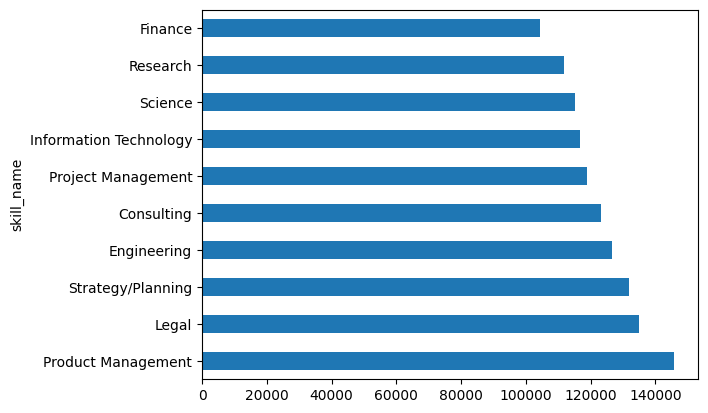

In [8]:
top_paying_skills=get_top_paying_skills(skills_df,10)
top_paying_skills.plot(kind="barh")

In [11]:
role_skills=get_role_skills(skills_df,"Software Engineer")
role_skills

skill_name
Engineering               158
Information Technology    129
Analyst                    34
Research                   32
Consulting                  3
Design                      2
Other                       2
Science                     2
Finance                     2
Project Management          1
Name: count, dtype: int64

### Demonstrate the skill_gap() function:

Skill Gap Analysis
This section demonstrates how the analytics engine identifies missing skills required for a target role.

In [12]:
user_skills = [
    "Sales",
    "Management",
    "Business Development"
]

result = skill_gap(
    user_skills,
    "Sales Manager",
    skills_df
)

print(result)

{'have': ['sales', 'business development', 'management'], 'missing': ['training', 'manufacturing', 'distribution', 'customer service', 'strategy/planning', 'finance', 'general business']}


In [13]:
user_skills = [
    "Information Technology",
    "Engineering"
]

result = skill_gap(
    user_skills,
    "Software Engineer",
    skills_df
)

print(result)

{'have': ['engineering', 'information technology'], 'missing': ['analyst', 'research', 'consulting', 'design', 'other', 'science', 'finance', 'project management']}


In [14]:
user_skills = [
    "Finance",
    "Accounting/Auditing"
]

result = skill_gap(
    user_skills,
    "Account Manager",
    skills_df
)

print(result)

{'have': ['accounting/auditing'], 'missing': ['sales', 'business development', 'customer service', 'management', 'marketing', 'project management', 'manufacturing', 'administrative', 'general business']}


### Business Insights:

In [16]:
get_top_skills(skills_df, 1)

skill_name
Information Technology    25167
Name: count, dtype: int64

In [15]:
get_salary_stats(skills_df, "Engineering")

{'mean': np.float64(126718.62),
 'median': 120000.0,
 'p25': np.float64(88400.0),
 'p75': np.float64(157000.0),
 'count': np.int64(3727)}

In [17]:
grp=skills_df.groupby("skill_name")
grp["title"].nunique().sort_values().tail()

skill_name
Health Care Provider       9698
Manufacturing             10586
Sales                     11311
Management                12242
Information Technology    16817
Name: title, dtype: int64